# 01 — Data collection: Truth Social posts

Doel: een complete lokale dump opbouwen van Donald Trump's Truth Social posts
sinds februari 2022, opgeslagen als `data/raw/posts.parquet` met genormaliseerd schema.

**Drie kanalen, in volgorde van voorkeur:**

| Kanaal | Pro | Con |
|---|---|---|
| `truthbrush` (Stanford IO) | Live data, alle metadata | Vereist Truth Social login, ToS-grijszone, scraper kan breken |
| Archive download (`trumpstruth.org`) | Stabiel, geen auth, regelmatig geüpdatet | Niet altijd up-to-date, schema kan wijzigen |
| Synthetic fallback | Werkt offline, snel iteratief testen | Niet bruikbaar voor finale resultaten |

**Strategie**: download eerst een complete archive dump (stabiel) voor de bulk
historische data, dan eventueel `truthbrush` voor de laatste dagen.


In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import warnings
from datetime import datetime
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"pandas={pd.__version__}, numpy={np.__version__}")

pandas=2.3.3, numpy=2.2.6


## Optie A — `truthbrush` (live scraper)

Setup:

```bash
pip install truthbrush
export TRUTHSOCIAL_USERNAME=<jouw_truthsocial_login>
export TRUTHSOCIAL_PASSWORD=<jouw_password>
```

⚠️ Maak een **wegwerp-account** aan, niet je persoonlijke. Truth Social kan accounts bannen
voor scraping. Voor academisch gebruik is dit verdedigbaar maar vermeld het netjes
in je methodologie.

Library: <https://github.com/stanfordio/truthbrush>


In [2]:
def fetch_posts_truthbrush(
    user: str = "realDonaldTrump",
    created_after: str | None = None,
) -> pd.DataFrame:
    """Wrapper rond truthbrush.

    Vereist environment variables TRUTHSOCIAL_USERNAME en TRUTHSOCIAL_PASSWORD.
    """
    if not (os.getenv("TRUTHSOCIAL_USERNAME") and os.getenv("TRUTHSOCIAL_PASSWORD")):
        raise RuntimeError("Set TRUTHSOCIAL_USERNAME en TRUTHSOCIAL_PASSWORD eerst.")

    from truthbrush.api import Api  # local import — alleen nodig voor live mode
    api = Api()
    statuses = api.pull_statuses(username=user, created_after=created_after, replies=False)

    rows = []
    for s in statuses:
        rows.append({
            "post_id": s.get("id"),
            "timestamp_utc": s.get("created_at"),
            "text": s.get("content", ""),
            "favorites": s.get("favourites_count", 0),
            "reposts": s.get("reblogs_count", 0),
            "replies": s.get("replies_count", 0),
            "url": s.get("url"),
        })
    df = pd.DataFrame(rows)
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    return df.sort_values("timestamp_utc").reset_index(drop=True)

## Optie B — archive download

`trumpstruth.org` host een doorlopende dump van alle Trump posts. De feitelijke
endpoint kan wijzigen — check de site voor de actuele download link, of bouw
een eigen scraper die paginatie afhandelt.

Verwacht schema (na normalisatie):

| Kolom | Type | Voorbeeld |
|---|---|---|
| `post_id` | str | "112345678901234567" |
| `timestamp_utc` | datetime | 2024-03-15 14:32:00+00:00 |
| `text` | str | "Just spoke to..." |
| `favorites` | int | 12345 |
| `reposts` | int | 3210 |
| `replies` | int | 890 |
| `url` | str | "https://truthsocial.com/..." |


In [3]:
def fetch_posts_archive(path: str | Path) -> pd.DataFrame:
    """Load posts from a local CSV/JSON dump.

    Pas de kolom-mapping aan op het daadwerkelijke schema van je dump.
    """
    path = Path(path)
    if path.suffix == ".csv":
        df = pd.read_csv(path)
    elif path.suffix in {".json", ".jsonl"}:
        df = pd.read_json(path, lines=path.suffix == ".jsonl")
    elif path.suffix == ".parquet":
        df = pd.read_parquet(path)
    else:
        raise ValueError(f"Unsupported format: {path.suffix}")

    # Normalize naar canonical schema
    rename_map = {
        "id": "post_id",
        "created_at": "timestamp_utc",
        "content": "text",
        "favourites_count": "favorites",
        "reblogs_count": "reposts",
        "replies_count": "replies",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    required = {"post_id", "timestamp_utc", "text"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Archive mist verplichte kolommen: {missing}")

    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    return df.sort_values("timestamp_utc").reset_index(drop=True)

## Optie C — synthetic fallback

Voor offline iteratie en als de andere kanalen falen. Genereert plausibele
posts met realistische topic-distributie (handel, Fed, olie, China, etc.) en
realistische volume-patronen (Poisson-verdeeld, ~10 posts/dag gemiddeld met
spikes). Niet bruikbaar voor finale resultaten — alleen om de pipeline te testen.


In [4]:
TOPIC_VOCAB = {
    "trade": [
        "tariffs are working great",
        "China is paying us billions in tariffs",
        "the trade deal will be massive",
        "we need fair trade not free trade",
        "bringing manufacturing back to America",
    ],
    "fed": [
        "the Fed should cut rates immediately",
        "Powell is way behind the curve",
        "interest rates are too high",
        "Fed Chair making a big mistake on rates",
        "we have no inflation thanks to my policies",
    ],
    "energy": [
        "drill baby drill",
        "we need cheap energy for American families",
        "Saudi Arabia must increase oil production",
        "OPEC playing games with oil prices",
        "energy independence is national security",
    ],
    "election": [
        "the polls look fantastic",
        "tremendous rally tonight massive crowds",
        "the radical left is destroying our country",
        "we will Make America Great Again",
        "the silent majority is with us",
    ],
    "economy": [
        "best economy in history",
        "stock market hitting all time highs",
        "jobs jobs jobs",
        "GDP growth is incredible",
        "inflation is being defeated",
    ],
    "media": [
        "fake news media wont report this",
        "CNN ratings have collapsed",
        "the failing New York Times strikes again",
        "media is the enemy of the people",
    ],
}


def synthesize_posts(
    n_days: int = 1500,
    posts_per_day_lambda: float = 12.0,
    start_date: str = "2022-02-21",
    seed: int = 42,
) -> pd.DataFrame:
    """Genereer plausibele Truth Social posts voor offline testing."""
    rng = np.random.default_rng(seed)
    start = pd.Timestamp(start_date, tz="UTC")

    rows = []
    for day_offset in range(n_days):
        date = start + pd.Timedelta(days=day_offset)
        n_posts = rng.poisson(posts_per_day_lambda)
        for _ in range(n_posts):
            topic = rng.choice(list(TOPIC_VOCAB.keys()))
            n_phrases = rng.integers(1, 4)
            phrases = rng.choice(TOPIC_VOCAB[topic], size=n_phrases, replace=True)
            text = ". ".join(phrases).capitalize() + "!"
            # Realistisch posting time — dag-bias rond US ochtend (12-20 UTC)
            hour = int(rng.choice(range(24), p=[
                0.01, 0.01, 0.01, 0.02, 0.02, 0.02, 0.02, 0.02,
                0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.09,
                0.08, 0.07, 0.06, 0.04, 0.03, 0.03, 0.03, 0.02,
            ]))
            minute = int(rng.integers(0, 60))
            timestamp = date.replace(hour=hour, minute=minute)
            rows.append({
                "post_id": f"synth_{len(rows):07d}",
                "timestamp_utc": timestamp,
                "text": text,
                "favorites": int(rng.lognormal(9, 1.5)),
                "reposts": int(rng.lognormal(7, 1.5)),
                "replies": int(rng.lognormal(7, 1.5)),
                "url": f"https://example.synthetic/post/{len(rows)}",
            })

    df = pd.DataFrame(rows)
    df.attrs["source"] = "synthetic"
    return df.sort_values("timestamp_utc").reset_index(drop=True)

## Main: collection orchestrator

Probeer in deze volgorde: archive → truthbrush → synthetic. Eerste die werkt wint.


In [5]:
ARCHIVE_PATH = Path("../data/raw/trump_truth_archive.csv")  # download dit zelf eerst


def collect() -> pd.DataFrame:
    # Optie B: lokale archive
    if ARCHIVE_PATH.exists():
        print(f"→ Loading from archive: {ARCHIVE_PATH}")
        return fetch_posts_archive(ARCHIVE_PATH)

    # Optie A: truthbrush live
    if os.getenv("TRUTHSOCIAL_USERNAME") and os.getenv("TRUTHSOCIAL_PASSWORD"):
        try:
            print("→ Fetching live via truthbrush…")
            df = fetch_posts_truthbrush()
            df.attrs["source"] = "truthbrush"
            return df
        except Exception as e:
            print(f"!!! truthbrush failed: {type(e).__name__}: {e}")

    # Optie C: synthetic fallback
    print("→ Geen live source beschikbaar — fallback op synthetic data.")
    return synthesize_posts()


posts = collect()
print(f"\nSource:  {posts.attrs.get('source', 'unknown')}")
print(f"Shape:   {posts.shape}")
print(f"Date range: {posts['timestamp_utc'].min()} → {posts['timestamp_utc'].max()}")
posts.head()

→ Geen live source beschikbaar — fallback op synthetic data.



Source:  synthetic
Shape:   (17894, 7)
Date range: 2022-02-21 04:51:00+00:00 → 2026-03-31 23:21:00+00:00


,post_id,timestamp_utc,text,favorites,reposts,replies,url
0,synth_0000002,2022-02-21 04:51:00+00:00,The radical left is destroying our country!,7518,831,394,https://example.synthetic/post/2
1,synth_0000005,2022-02-21 07:41:00+00:00,We need fair trade not free trade. tariffs are...,2352,2909,3343,https://example.synthetic/post/5
2,synth_0000007,2022-02-21 08:49:00+00:00,Powell is way behind the curve. powell is way ...,8967,1692,2826,https://example.synthetic/post/7
3,synth_0000011,2022-02-21 11:03:00+00:00,Bringing manufacturing back to america!,10033,3089,577,https://example.synthetic/post/11
4,synth_0000010,2022-02-21 13:01:00+00:00,Gdp growth is incredible!,29347,823,161,https://example.synthetic/post/10


## Data quality checks


In [6]:
# Schema overview
print("--- Dtypes ---")
print(posts.dtypes)
print()
print("--- Missing values ---")
print(posts.isna().sum())
print()
print("--- Duplicate post_ids ---")
print(f"  {posts['post_id'].duplicated().sum()}")
print()
print("--- Timestamps monotonic? ---")
print(f"  {posts['timestamp_utc'].is_monotonic_increasing}")

--- Dtypes ---
post_id                       object
timestamp_utc    datetime64[ns, UTC]
text                          object
favorites                      int64
reposts                        int64
replies                        int64
url                           object
dtype: object

--- Missing values ---
post_id          0
timestamp_utc    0
text             0
favorites        0
reposts          0
replies          0
url              0
dtype: int64

--- Duplicate post_ids ---
  0

--- Timestamps monotonic? ---
  True


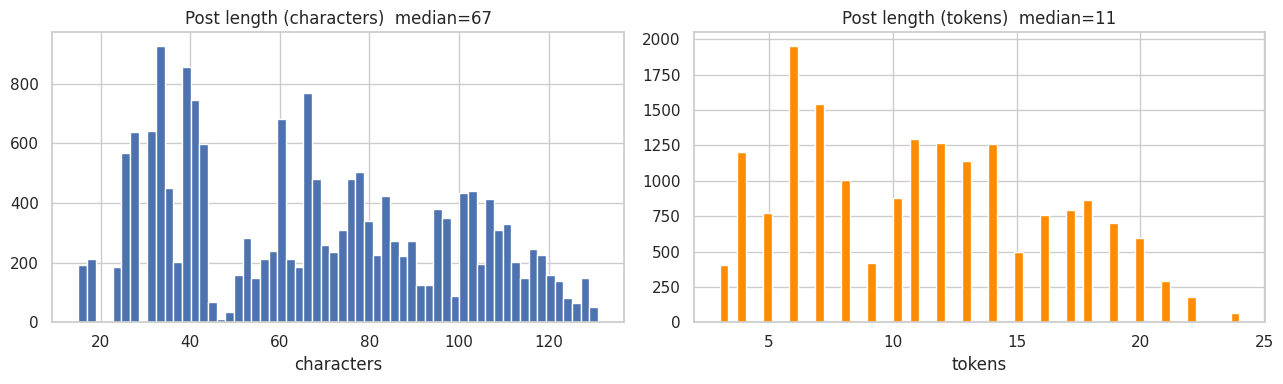

Posts < 5 tokens: 1607  (9.0%)
Posts > 100 tokens: 0  (0.0%)


In [7]:
# Tekstlengte distributie (in tokens, ruwe whitespace split)
posts["n_chars"] = posts["text"].str.len()
posts["n_tokens"] = posts["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(posts["n_chars"], bins=60, edgecolor="white")
axes[0].set_title(f"Post length (characters)  median={posts['n_chars'].median():.0f}")
axes[0].set_xlabel("characters")

axes[1].hist(posts["n_tokens"], bins=60, edgecolor="white", color="darkorange")
axes[1].set_title(f"Post length (tokens)  median={posts['n_tokens'].median():.0f}")
axes[1].set_xlabel("tokens")
fig.tight_layout()
plt.show()

print(f"Posts < 5 tokens: {(posts['n_tokens'] < 5).sum()}  ({(posts['n_tokens'] < 5).mean()*100:.1f}%)")
print(f"Posts > 100 tokens: {(posts['n_tokens'] > 100).sum()}  ({(posts['n_tokens'] > 100).mean()*100:.1f}%)")

## Volume over tijd


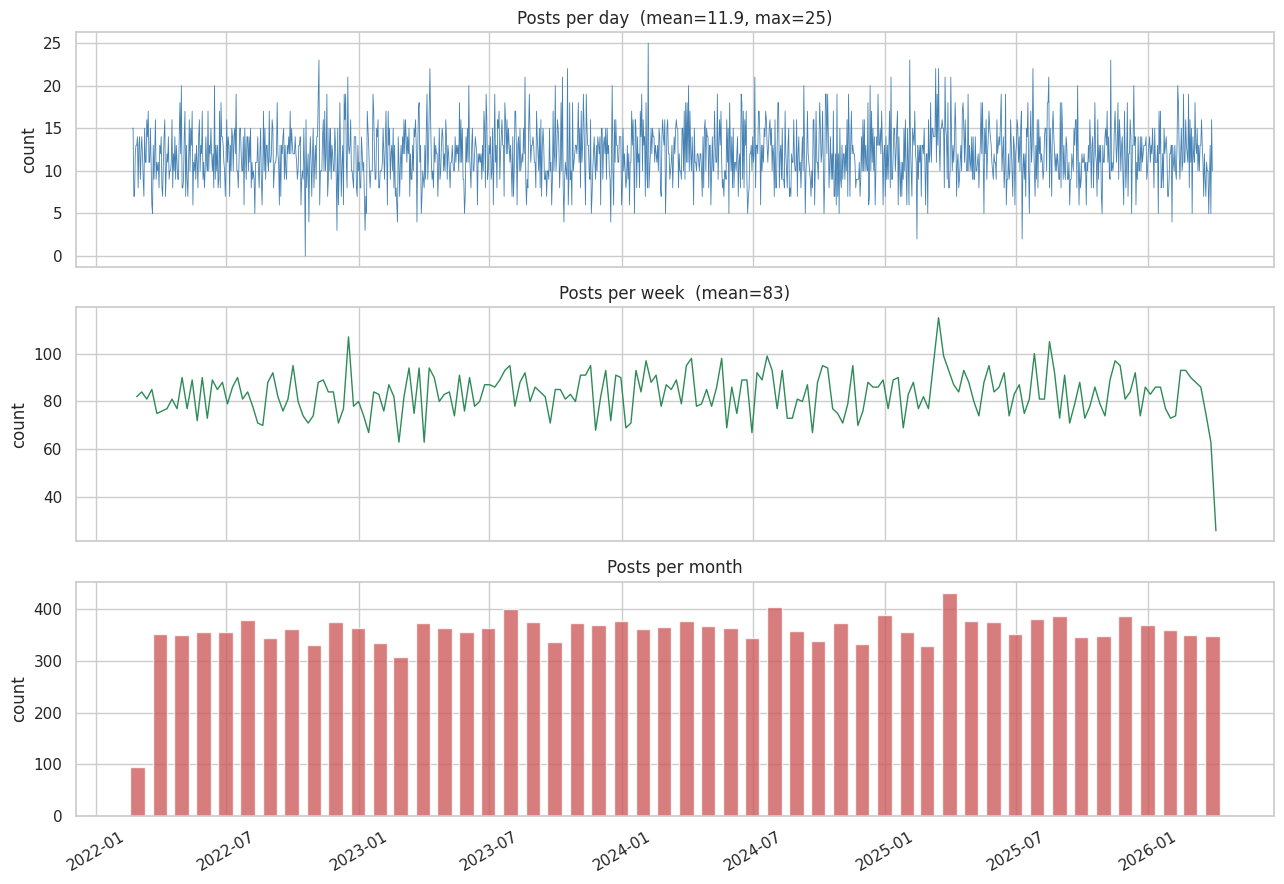

In [8]:
posts_per_day = posts.set_index("timestamp_utc").resample("D").size().rename("n_posts")
posts_per_week = posts.set_index("timestamp_utc").resample("W").size().rename("n_posts")
posts_per_month = posts.set_index("timestamp_utc").resample("ME").size().rename("n_posts")

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
axes[0].plot(posts_per_day.index, posts_per_day.values, linewidth=0.6, color="steelblue")
axes[0].set_title(f"Posts per day  (mean={posts_per_day.mean():.1f}, max={posts_per_day.max()})")
axes[0].set_ylabel("count")

axes[1].plot(posts_per_week.index, posts_per_week.values, linewidth=1.0, color="seagreen")
axes[1].set_title(f"Posts per week  (mean={posts_per_week.mean():.0f})")
axes[1].set_ylabel("count")

axes[2].bar(posts_per_month.index, posts_per_month.values, width=20, color="indianred", alpha=0.8)
axes[2].set_title("Posts per month")
axes[2].set_ylabel("count")
axes[2].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

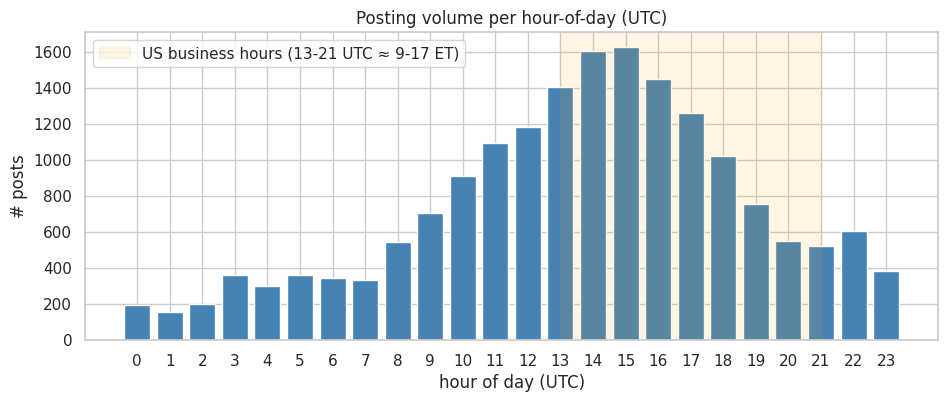

In [9]:
# Wanneer op de dag wordt gepost? (UTC)
hour_dist = posts["timestamp_utc"].dt.hour.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(hour_dist.index, hour_dist.values, color="steelblue", edgecolor="white")
ax.set_title("Posting volume per hour-of-day (UTC)")
ax.set_xlabel("hour of day (UTC)")
ax.set_ylabel("# posts")
ax.set_xticks(range(0, 24))
# US-Eastern reference
ax.axvspan(13, 21, alpha=0.1, color="orange", label="US business hours (13-21 UTC ≈ 9-17 ET)")
ax.legend()
plt.show()

## Vocabulary preview

Top-30 woorden na simpele stopwords-filter. Niet voor productie — gebruik
NLTK/spaCy voor degelijke preprocessing in notebook 04. Hier alleen sanity check.


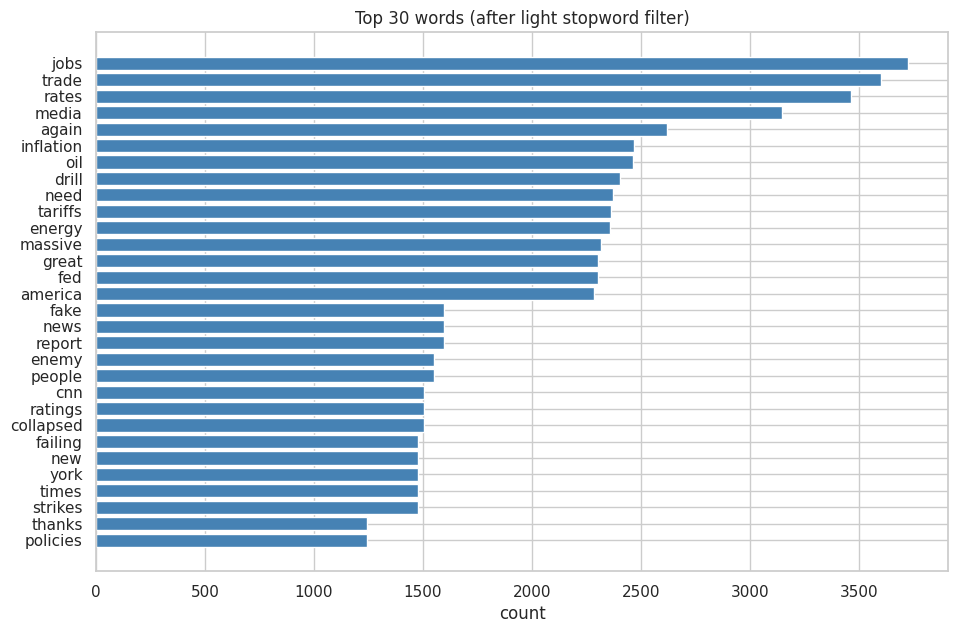

,word,count
0,jobs,3723
1,trade,3598
2,rates,3462
3,media,3147
4,again,2619
5,inflation,2465
6,oil,2464
7,drill,2404
8,need,2370
9,tariffs,2361


In [10]:
STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "has", "have",
    "i", "in", "is", "it", "its", "of", "on", "or", "our", "so", "that", "the",
    "this", "to", "was", "were", "will", "with", "you", "your", "we", "us", "they",
    "them", "their", "but", "not", "no", "do", "does", "did", "if", "all", "my",
    "me", "im", "ive", "youre", "thats", "im", "its", "dont", "wont",
}

from collections import Counter
import re

words = []
for t in posts["text"].str.lower():
    tokens = re.findall(r"[a-z]+", t)
    words.extend(w for w in tokens if w not in STOPWORDS and len(w) > 2)

word_counts = Counter(words)
top30 = word_counts.most_common(30)

top_df = pd.DataFrame(top30, columns=["word", "count"])
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_df["word"][::-1], top_df["count"][::-1], color="steelblue")
ax.set_title("Top 30 words (after light stopword filter)")
ax.set_xlabel("count")
plt.show()
top_df.head(10)

## Save processed


In [11]:
out_path = Path("../data/raw/posts.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)

# Drop temporary EDA columns voor de raw output
to_save = posts.drop(columns=["n_chars", "n_tokens"], errors="ignore")
to_save.to_parquet(out_path, index=False)
print(f"Wrote {len(to_save):,} posts to {out_path.resolve()}")
print(f"Columns: {list(to_save.columns)}")
print(f"Source:  {posts.attrs.get('source', 'unknown')}")

Wrote 17,894 posts to /sessions/confident-blissful-clarke/mnt/outputs/truthsocial-marketimpact/data/raw/posts.parquet
Columns: ['post_id', 'timestamp_utc', 'text', 'favorites', 'reposts', 'replies', 'url']
Source:  synthetic


## Bevindingen & next steps

**Wat we hebben gezien** (vul aan op basis van je echte run):
- N posts over [periode], gemiddeld X per dag.
- Posting concentreert zich rond US ochtend (UTC 13-20).
- Geen problematische missing values of duplicates.

**Volgende stap (notebook 03 — alignment):**
- Posts joinen aan marktbewegingen via `merge_asof` (post → next trading open).
- Compute abnormal returns voor S&P 500 en WTI per post per window.
- Output: `data/processed/aligned.parquet` met (post_id, AR_1d_spx, AR_1d_wti, …).

**Open vragen voor begeleider:**
- Truth Social weekend posts: alignen naar maandag open of skipen?
- Reposts (geen originele content) wel/niet meenemen?
- Posts met enkel een link/image (text < 5 tokens) excluden?
